In [ ]:
# ======================================
# Section 1 - Imports and Setup
# ======================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
!pip install python-binance
from binance.client import Client as bnb_client
!pip install statsmodels
import statsmodels.api as sm

client = bnb_client(tld='US')  # Choosing US Binance data

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.5/148.5 kB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.4/300.4 kB 32.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 100.9 MB/s eta 0:00:00


In [ ]:
# =======================================
# Section 2 - Universe Filters and Data Loading
# =======================================
stable_coins = {'USDCUSDT', 'FDUSDUSDT', 'TUSDUSDT', 'USDPUSDT', 'DAIUSDT', 'BUSDUSDT', 'USDSUSDT'}
wrapped = {'WBTCUSDT', 'WBETHUSDT'}

def is_leveraged(symbol: str) -> bool:
    bad_patterns = ['UPUSDT', 'DOWNUSDT', 'BULLUSDT', 'BEARUSDT']
    return any(symbol.endswith(x) for x in bad_patterns)

def is_valid_usdt(symbol: str) -> bool:
    if not symbol.endswith('USDT'):
        return False
    if symbol in stable_coins:
        return False
    if symbol in wrapped:
        return False
    if is_leveraged(symbol):
        return False
    return True

exchange_info = client.get_exchange_info()

candidate_symbols = []
for s in exchange_info['symbols']:
    symbol = s['symbol']
    status = s.get('status', '')
    is_spot_allowed = s.get('isSpotTradingAllowed', False)

    if status == 'TRADING' and is_spot_allowed and is_valid_usdt(symbol):
        candidate_symbols.append(symbol)

candidate_symbols = sorted(candidate_symbols)

print(f'Number of candidate symbols: {len(candidate_symbols)}')
print(candidate_symbols[:30])

def get_binance_data(symbol, freq, start_date='2018-01-01', end_date='2025-12-31'):
    data = client.get_historical_klines(symbol, freq, start_date, end_date)
    columns = [
        'open_time', 'open', 'high', 'low', 'close', 'volume',
        'close_time', 'quote_volume', 'num_trades',
        'taker_base_volume', 'taker_quote_volume', 'ignore'
    ]

    data = pd.DataFrame(data, columns=columns)

    if data.empty:
        return data

    data['open_time'] = pd.to_datetime(data['open_time'], unit='ms', utc=True).dt.tz_localize(None)
    data['close_time'] = pd.to_datetime(data['close_time'], unit='ms', utc=True).dt.tz_localize(None)

    numeric_cols = [
        'open', 'high', 'low', 'close', 'volume',
        'quote_volume', 'num_trades', 'taker_base_volume', 'taker_quote_volume'
    ]
    for col in numeric_cols:
        data[col] = pd.to_numeric(data[col], errors='coerce')

    return data

freq = '4h'
close_dict = {}
vol_dict = {}

for symbol in candidate_symbols:
    try:
        data = get_binance_data(symbol, freq)

        if data.empty:
            continue

        s_close = data.set_index('open_time')['close'].sort_index()
        s_volume = data.set_index('open_time')['volume'].sort_index()

        if len(s_close.dropna()) < 200:
            continue

        close_dict[symbol] = s_close
        vol_dict[symbol] = s_volume

    except Exception as e:
        print(f"Skipping {symbol} due to Error: {e}")

px = pd.DataFrame(close_dict).sort_index()
px_vol = pd.DataFrame(vol_dict).sort_index()

print(f"Price shape: {px.shape}")
print(f"Volume shape: {px_vol.shape}")
print(f"Number of symbols: {px.shape[1]}")

ret = px.pct_change(fill_method=None)

Number of candidate symbols: 198
['1000MOGUSDT', '1000REKTUSDT', '1INCHUSDT', 'A2ZUSDT', 'AAVEUSDT', 'ACHUSDT', 'ADAUSDT', 'ADXUSDT', 'AIXBTUSDT', 'ALGOUSDT', 'ALICEUSDT', 'ALPINEUSDT', 'ANIMEUSDT', 'ANKRUSDT', 'APEUSDT', 'API3USDT', 'APTUSDT', 'ARBUSDT', 'ASTERUSDT', 'ASTRUSDT', 'ATOMUSDT', 'AUDIOUSDT', 'AUSDT', 'AVAXUSDT', 'AVNTUSDT', 'AXLUSDT', 'AXSUSDT', 'BANDUSDT', 'BATUSDT', 'BCHUSDT']
Price shape: (13739, 188)
Volume shape: (13739, 188)
Number of symbols: 188


In [ ]:
# ===========================================
# Section 3 - Universe Construction
# ===========================================
def compute_dollar_volume(close_df, volume_df):
    return close_df * volume_df

def make_weekly_universe(close_df, volume_df, top_n=15, min_history_bar=90*6, adv_window_bar=30*6):
    dollar_volume = compute_dollar_volume(close_df, volume_df)

    adv_30 = dollar_volume.rolling(adv_window_bar, min_periods=adv_window_bar).mean()

    history_ok = (
        close_df.notna()
        .rolling(min_history_bar, min_periods=min_history_bar)
        .sum()
        .eq(min_history_bar)
    )

    liquid_ok = adv_30.notna() & adv_30.gt(0)
    price_ok = close_df.notna() & close_df.gt(0)

    eligible = history_ok & price_ok & liquid_ok

    weekly_adv30 = adv_30.resample('7D').last()
    weekly_eligible = eligible.resample('7D').last()

    universe = pd.DataFrame(False, index=weekly_adv30.index, columns=weekly_adv30.columns)

    for dt in weekly_adv30.index:
        scores = weekly_adv30.loc[dt].where(weekly_eligible.loc[dt], np.nan)
        selected = scores.nlargest(top_n).dropna().index
        universe.loc[dt, selected] = True

    return universe

weekly_universe = make_weekly_universe(px, px_vol, top_n=15)

print("Weekly universe shape:", weekly_universe.shape)
print("Average number of names selected:", weekly_universe.sum(axis=1).mean())

Weekly universe shape: (328, 188)
Average number of names selected: 14.362804878048781


In [ ]:
# =========================================
# Section 4 - Weekly Returns
# =========================================
def create_weekly_returns(ret_4h):
    weekly_ret = (1 + ret_4h).resample('7D').prod(min_count=1) - 1
    return weekly_ret

def create_weekly_volume(volume_4h):
    weekly_vol = volume_4h.resample('7D').sum(min_count=1)
    return weekly_vol

weekly_returns = create_weekly_returns(ret)
weekly_volume = create_weekly_volume(px_vol)

weekly_universe = weekly_universe.reindex(weekly_returns.index).fillna(False)

print("weekly_returns shape:", weekly_returns.shape)
print("weekly_volume shape:", weekly_volume.shape)
print("weekly_universe shape:", weekly_universe.shape)

weekly_returns shape: (328, 188)
weekly_volume shape: (328, 188)
weekly_universe shape: (328, 188)


In [ ]:
# ==================================
# Section 5 - Signal Builders
# ==================================
# ---------------plain momentum helpers--------------------------
def create_momentum(weekly_ret, lookback_weeks=12, skip_weeks=1):
    shifted = weekly_ret.shift(skip_weeks)
    mom = (1 + shifted).rolling(lookback_weeks, min_periods=lookback_weeks).apply(np.prod, raw=True) - 1
    return mom

def build_bucket_weights(signal, universe_mask, top_frac=0.2):
    signal_in_universe = signal.where(universe_mask)
    weights = pd.DataFrame(0.0, index=signal.index, columns=signal.columns)

    for dt in signal.index:
        row = signal_in_universe.loc[dt].dropna()

        if len(row) < 4:
            continue

        n_assets = len(row)
        k = max(1, int(np.floor(top_frac * n_assets)))

        winners = row.nlargest(k).index
        losers = row.nsmallest(k).index

        weights.loc[dt, winners] = 1.0 / k
        weights.loc[dt, losers] = -1.0 / k
        weights.loc[dt] = 0.5 * weights.loc[dt]

    return weights

def build_signal_momentum_buckets(weekly_returns, weekly_universe, lookback_weeks=12, skip_weeks=1, top_frac=0.2):
    mom = create_momentum(
        weekly_returns,
        lookback_weeks=lookback_weeks,
        skip_weeks=skip_weeks
    )

    weights = build_bucket_weights(
        signal=mom.shift(1),
        universe_mask=weekly_universe,
        top_frac=top_frac
    )

    return weights

# -------- residual momentum helpers --------
def compute_residual_returns(weekly_returns, benchmark_returns, beta_lookback=12):
    residuals = pd.DataFrame(index=weekly_returns.index, columns=weekly_returns.columns, dtype=float)
    bench_var = benchmark_returns.rolling(beta_lookback).var()

    for col in weekly_returns.columns:
        asset_ret = weekly_returns[col]
        cov = asset_ret.rolling(beta_lookback).cov(benchmark_returns)
        beta = cov / bench_var
        residuals[col] = asset_ret - beta * benchmark_returns

    return residuals

def build_signal_residual_momentum_buckets(
    weekly_returns,
    weekly_universe,
    benchmark_returns,
    lookback_weeks=4,
    skip_weeks=0,
    top_frac=0.4,
    beta_lookback=12
):
    residual_returns = compute_residual_returns(
        weekly_returns=weekly_returns,
        benchmark_returns=benchmark_returns,
        beta_lookback=beta_lookback
    )

    residual_mom = create_momentum(
        residual_returns,
        lookback_weeks=lookback_weeks,
        skip_weeks=skip_weeks
    )

    weights = build_bucket_weights(
        signal=residual_mom.shift(1),
        universe_mask=weekly_universe,
        top_frac=top_frac
    )

    return weights, residual_returns, residual_mom

In [ ]:
# ===================================================
# Section 6 - Helper Functions
# ===================================================
def run_backtest(weights, returns, tc=0.002):
    aligned_weights = weights.reindex_like(returns).fillna(0.0)

    gross_asset_ret = aligned_weights * returns
    gross_port_ret = gross_asset_ret.sum(axis=1)

    turnover = aligned_weights.diff().abs().sum(axis=1).fillna(0.0)
    net_port_ret = gross_port_ret - tc * turnover

    return gross_port_ret, net_port_ret, turnover

def apply_vol_target(weights, returns, target_vol=0.20, lookback_weeks=12, annualization=52, max_leverage=1.5):
    aligned_weights = weights.reindex_like(returns).fillna(0.0)
    base_port_ret = (aligned_weights * returns).sum(axis=1)
    realized_vol = base_port_ret.rolling(lookback_weeks).std() * np.sqrt(annualization)

    scaler = (target_vol / realized_vol).replace([np.inf, -np.inf], np.nan)
    scaler = scaler.clip(upper=max_leverage).shift(1).fillna(1.0)

    scaled_weights = aligned_weights.mul(scaler, axis=0)

    return scaled_weights, scaler, realized_vol

def cumulative_return(ret_series):
    return (1 + ret_series.fillna(0)).cumprod()

def max_drawdown(ret_series):
    wealth = cumulative_return(ret_series)
    running_max = wealth.cummax()
    drawdown = wealth / running_max - 1
    return drawdown.min(), drawdown

def annualized_sharpe(ret_series, periods_per_year=52):
    ret_series = ret_series.dropna()
    if ret_series.std() == 0:
        return np.nan
    return np.sqrt(periods_per_year) * ret_series.mean() / ret_series.std()

def regression_alpha_beta(strategy_returns, benchmark_returns):
    reg = pd.concat([
        strategy_returns.rename("strategy"),
        benchmark_returns.rename("benchmark")
    ], axis=1).dropna()

    Y = reg["strategy"].astype(float)
    X = sm.add_constant(reg["benchmark"].astype(float))
    results = sm.OLS(Y, X).fit()

    alpha_weekly = results.params["const"]
    beta = results.params["benchmark"]
    alpha_annual = alpha_weekly * 52

    return reg, results, alpha_weekly, alpha_annual, beta

def evaluate_model(train_series, test_series, train_benchmark, test_benchmark, turnover_train, turnover_test, model_name):
    reg_train, results_train, alpha_w_train, alpha_ann_train, beta_train = regression_alpha_beta(
        train_series, train_benchmark
    )
    reg_test, results_test, alpha_w_test, alpha_ann_test, beta_test = regression_alpha_beta(
        test_series, test_benchmark
    )

    out = {
        "Model": model_name,
        "Train Sharpe": annualized_sharpe(train_series, periods_per_year=52),
        "Test Sharpe": annualized_sharpe(test_series, periods_per_year=52),
        "Train Alpha vs BTC": alpha_ann_train,
        "Test Alpha vs BTC": alpha_ann_test,
        "Train Beta vs BTC": beta_train,
        "Test Beta vs BTC": beta_test,
        "Train Corr vs BTC": reg_train['benchmark'].corr(reg_train['strategy']),
        "Test Corr vs BTC": reg_test['benchmark'].corr(reg_test['strategy']),
        "Train MDD": max_drawdown(train_series)[0],
        "Test MDD": max_drawdown(test_series)[0],
        "Train Turnover": turnover_train.mean(),
        "Test Turnover": turnover_test.mean()
    }

    return out, results_train, results_test

def mean_return_tstats(ret_series, lags=4):
    y = ret_series.dropna().astype(float)
    X = np.ones(len(y))

    ols_plain = sm.OLS(y, X).fit()
    ols_hac = sm.OLS(y, X).fit(cov_type='HAC', cov_kwds={'maxlags': lags})

    out = {
        "n_obs": len(y),
        "mean_weekly_return": y.mean(),
        "std_weekly_return": y.std(),
        "plain_tstat": float(ols_plain.tvalues[0]),
        "plain_pvalue": float(ols_plain.pvalues[0]),
        "nw_tstat": float(ols_hac.tvalues[0]),
        "nw_pvalue": float(ols_hac.pvalues[0]),
        "annualized_mean_return": float(y.mean() * 52)
    }

    return out, ols_plain, ols_hac

In [ ]:
# =========================================
# Section 7 - Case 1: Plain Momentum
# =========================================
btc_bench = weekly_returns['BTCUSDT'].rename('BTC')
market_bench = weekly_returns.mean(axis=1).rename("EW_CRYPTO")

weights_case1 = build_signal_momentum_buckets(
    weekly_returns=weekly_returns,
    weekly_universe=weekly_universe,
    lookback_weeks=4,
    skip_weeks=0,
    top_frac=0.4
)

In [ ]:
# =========================================
# Section 8 - Case 2: Vol-Targeted Momentum
# =========================================
weights_case2_base = build_signal_momentum_buckets(
    weekly_returns=weekly_returns,
    weekly_universe=weekly_universe,
    lookback_weeks=4,
    skip_weeks=0,
    top_frac=0.4
)

weights_case2, scaler_case2, vol_case2 = apply_vol_target(
    weights=weights_case2_base,
    returns=weekly_returns,
    target_vol=0.20,
    lookback_weeks=12,
    annualization=52,
    max_leverage=1.5
)

In [ ]:
# =========================================
# Section 9 - Case 3: Residual Momentum
# =========================================
weights_case3, residual_returns_case3, residual_mom_case3 = build_signal_residual_momentum_buckets(
    weekly_returns=weekly_returns,
    weekly_universe=weekly_universe,
    benchmark_returns=market_bench,
    lookback_weeks=4,
    skip_weeks=0,
    top_frac=0.4,
    beta_lookback=12
)

In [ ]:
# =========================================
# Section 10 - Case 4: Residual Momentum + Vol Targeting
# =========================================
weights_case4_base, residual_returns_case4, residual_mom_case4 = build_signal_residual_momentum_buckets(
    weekly_returns=weekly_returns,
    weekly_universe=weekly_universe,
    benchmark_returns=market_bench,
    lookback_weeks=4,
    skip_weeks=0,
    top_frac=0.4,
    beta_lookback=12
)

weights_case4, scaler_case4, vol_case4 = apply_vol_target(
    weights=weights_case4_base,
    returns=weekly_returns,
    target_vol=0.20,
    lookback_weeks=12,
    annualization=52,
    max_leverage=1.5
)

In [ ]:

# =========================================
# Section 11 - 4y / 2y / 2y Comparison Tables
# =========================================
splits = {
    "4y_train_2y_val_2y_oos": {
        "train_start": "2018-01-01",
        "train_end": "2021-12-31",
        "val_start": "2022-01-01",
        "val_end": "2023-12-31",
        "oos_start": "2024-01-01",
        "oos_end": "2025-12-31"
    }
}

def evaluate_case(case_name, weights_full, split_cfg, tc=0.002, nw_lags=4):
    train_mask = (weekly_returns.index >= split_cfg["train_start"]) & (weekly_returns.index <= split_cfg["train_end"])
    val_mask   = (weekly_returns.index >= split_cfg["val_start"]) & (weekly_returns.index <= split_cfg["val_end"])
    oos_mask   = (weekly_returns.index >= split_cfg["oos_start"]) & (weekly_returns.index <= split_cfg["oos_end"])

    train_returns = weekly_returns.loc[train_mask]
    val_returns   = weekly_returns.loc[val_mask]
    oos_returns   = weekly_returns.loc[oos_mask]

    weights_train = weights_full.loc[train_mask]
    weights_val   = weights_full.loc[val_mask]
    weights_oos   = weights_full.loc[oos_mask]

    gross_train, net_train, turnover_train = run_backtest(weights_train, train_returns, tc=tc)
    gross_val,   net_val,   turnover_val   = run_backtest(weights_val,   val_returns,   tc=tc)
    gross_oos,   net_oos,   turnover_oos   = run_backtest(weights_oos,   oos_returns,   tc=tc)

    btc_train = btc_bench.loc[train_mask]
    btc_val   = btc_bench.loc[val_mask]
    btc_oos   = btc_bench.loc[oos_mask]

    train_summary, train_reg, _ = evaluate_model(
        net_train, net_val, btc_train, btc_val, turnover_train, turnover_val, case_name + " (Train vs Val helper)"
    )

    reg_train, results_train, alpha_w_train, alpha_ann_train, beta_train = regression_alpha_beta(net_train, btc_train)
    reg_val, results_val, alpha_w_val, alpha_ann_val, beta_val = regression_alpha_beta(net_val, btc_val)
    reg_oos, results_oos, alpha_w_oos, alpha_ann_oos, beta_oos = regression_alpha_beta(net_oos, btc_oos)

    train_tstats, _, _ = mean_return_tstats(net_train, lags=nw_lags)
    val_tstats, _, _   = mean_return_tstats(net_val, lags=nw_lags)
    oos_tstats, _, _   = mean_return_tstats(net_oos, lags=nw_lags)

    summary = {
        "Model": case_name,

        "Train Sharpe": annualized_sharpe(net_train, periods_per_year=52),
        "Validation Sharpe": annualized_sharpe(net_val, periods_per_year=52),
        "OOS Sharpe": annualized_sharpe(net_oos, periods_per_year=52),

        "Train Alpha vs BTC": alpha_ann_train,
        "Validation Alpha vs BTC": alpha_ann_val,
        "OOS Alpha vs BTC": alpha_ann_oos,

        "Train Beta vs BTC": beta_train,
        "Validation Beta vs BTC": beta_val,
        "OOS Beta vs BTC": beta_oos,

        "Train MDD": max_drawdown(net_train)[0],
        "Validation MDD": max_drawdown(net_val)[0],
        "OOS MDD": max_drawdown(net_oos)[0],

        "Train Turnover": turnover_train.mean(),
        "Validation Turnover": turnover_val.mean(),
        "OOS Turnover": turnover_oos.mean(),

        "Train NW t-stat": train_tstats["nw_tstat"],
        "Validation NW t-stat": val_tstats["nw_tstat"],
        "OOS NW t-stat": oos_tstats["nw_tstat"],

        "Train NW p-value": train_tstats["nw_pvalue"],
        "Validation NW p-value": val_tstats["nw_pvalue"],
        "OOS NW p-value": oos_tstats["nw_pvalue"],

        "Train Mean Weekly Return": net_train.mean(),
        "Validation Mean Weekly Return": net_val.mean(),
        "OOS Mean Weekly Return": net_oos.mean()
    }

    extra = {
        "net_train": net_train,
        "net_val": net_val,
        "net_oos": net_oos,
        "strategy_train_val_oos": pd.concat([net_train, net_val, net_oos]).sort_index(),

        "train_dd": max_drawdown(net_train)[1],
        "val_dd": max_drawdown(net_val)[1],
        "oos_dd": max_drawdown(net_oos)[1],

        "results_train": results_train,
        "results_val": results_val,
        "results_oos": results_oos
    }

    return summary, extra

case_map = {
    "Case 1 - Plain": weights_case1,
    "Case 2 - Vol Targeted": weights_case2,
    "Case 3 - Residual": weights_case3,
    "Case 4 - Residual + Vol Targeted": weights_case4
}

all_results = []
all_extras = {}

split_name = "4y_train_2y_val_2y_oos"
split_cfg = splits[split_name]

for case_name, weights_case in case_map.items():
    summary, extra = evaluate_case(case_name, weights_case, split_cfg, tc=0.002, nw_lags=4)
    summary["Split Name"] = split_name
    all_results.append(summary)
    all_extras[(case_name, split_name)] = extra

results_df = pd.DataFrame(all_results).sort_values("Model").reset_index(drop=True)
validation_table = results_df[[
    "Model",
    "Validation Sharpe",
    "Validation Alpha vs BTC",
    "Validation Beta vs BTC",
    "Validation MDD",
    "Validation Turnover",
    "Validation NW t-stat",
    "Validation NW p-value",
    "Validation Mean Weekly Return"
]].copy()

print("Validation Results")
print(validation_table)

Validation Results
                              Model  Validation Sharpe  \
0                    Case 1 - Plain           0.771040   
1             Case 2 - Vol Targeted           0.917721   
2                 Case 3 - Residual          -0.154951   
3  Case 4 - Residual + Vol Targeted           0.160365   

   Validation Alpha vs BTC  Validation Beta vs BTC  Validation MDD  \
0                 0.164983                0.030743       -0.229858   
1                 0.194143                0.036655       -0.189594   
2                -0.034132                0.030437       -0.365710   
3                 0.031080                0.036125       -0.316627   

   Validation Turnover  Validation NW t-stat  Validation NW p-value  \
0             0.599359              1.213803               0.224823   
1             0.612539              1.356002               0.175099   
2             0.688782             -0.231086               0.817248   
3             0.729542              0.232278           

/tmp/ipykernel_1307/2314359596.py:95: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  "plain_tstat": float(ols_plain.tvalues[0]),
/tmp/ipykernel_1307/2314359596.py:96: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  "plain_pvalue": float(ols_plain.pvalues[0]),
/tmp/ipykernel_1307/2314359596.py:97: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  "nw_tstat": float(ols_hac.tvalues[0]),
/tmp/ipykernel_1307/2314359596.py:98: FutureWarning: Ser

Choosing Case 2 based on the above given data as the most suitable model in terms of Sharpe, alpha, t-stat and Drawdown. The exploratory idea of residual momentum was great to try out, but is not the primary chosen strategy.

In [ ]:
#OOS Data
oos_table = results_df[[
    "Model",
    "OOS Sharpe",
    "OOS Alpha vs BTC",
    "OOS Beta vs BTC",
    "OOS MDD",
    "OOS Turnover",
    "OOS NW t-stat",
    "OOS NW p-value",
    "OOS Mean Weekly Return"
]].copy()

print("OOS Results")
print(oos_table)

OOS Results
                              Model  OOS Sharpe  OOS Alpha vs BTC  \
0                    Case 1 - Plain    0.137366          0.030871   
1             Case 2 - Vol Targeted    0.283018          0.073557   
2                 Case 3 - Residual   -0.333865         -0.058261   
3  Case 4 - Residual + Vol Targeted   -0.683077         -0.121732   

   OOS Beta vs BTC   OOS MDD  OOS Turnover  OOS NW t-stat  OOS NW p-value  \
0         0.006293 -0.244758      0.628571       0.217185        0.828064   
1        -0.019473 -0.225956      0.618945       0.426208        0.669956   
2        -0.085454 -0.358158      0.667937      -0.524384        0.600012   
3        -0.164706 -0.451477      0.684335      -1.113519        0.265486   

   OOS Mean Weekly Return  
0                0.000650  
1                0.001240  
2               -0.001886  
3               -0.003816  


In [ ]:
comparison_cols = [
    "Model",
    "Train Sharpe", "Validation Sharpe", "OOS Sharpe",
    "Train Alpha vs BTC", "Validation Alpha vs BTC", "OOS Alpha vs BTC",
    "Train Beta vs BTC", "Validation Beta vs BTC", "OOS Beta vs BTC",
    "Train MDD", "Validation MDD", "OOS MDD",
    "Train Turnover", "Validation Turnover", "OOS Turnover",
    "Train NW t-stat", "Validation NW t-stat", "OOS NW t-stat",
    "Train NW p-value", "Validation NW p-value", "OOS NW p-value"
]

comparison_table = results_df[comparison_cols].copy()
print(comparison_table)
pivot_compare = results_df.set_index("Model")[[
    "Train Sharpe", "Validation Sharpe", "OOS Sharpe",
    "Train Alpha vs BTC", "Validation Alpha vs BTC", "OOS Alpha vs BTC",
    "Train NW t-stat", "Validation NW t-stat", "OOS NW t-stat",
    "Train MDD", "Validation MDD", "OOS MDD"
]]

print(pivot_compare)

                              Model  Train Sharpe  Validation Sharpe  \
0                    Case 1 - Plain      0.591234           0.771040   
1             Case 2 - Vol Targeted      0.838012           0.917721   
2                 Case 3 - Residual      0.225358          -0.154951   
3  Case 4 - Residual + Vol Targeted      0.384423           0.160365   

   OOS Sharpe  Train Alpha vs BTC  Validation Alpha vs BTC  OOS Alpha vs BTC  \
0    0.137366            0.269156                 0.164983          0.030871   
1    0.283018            0.199649                 0.194143          0.073557   
2   -0.333865            0.000753                -0.034132         -0.058261   
3   -0.683077            0.078677                 0.031080         -0.121732   

   Train Beta vs BTC  Validation Beta vs BTC  OOS Beta vs BTC  ...   OOS MDD  \
0           0.018399                0.030743         0.006293  ... -0.244758   
1           0.002417                0.036655        -0.019473  ... -0.225956  

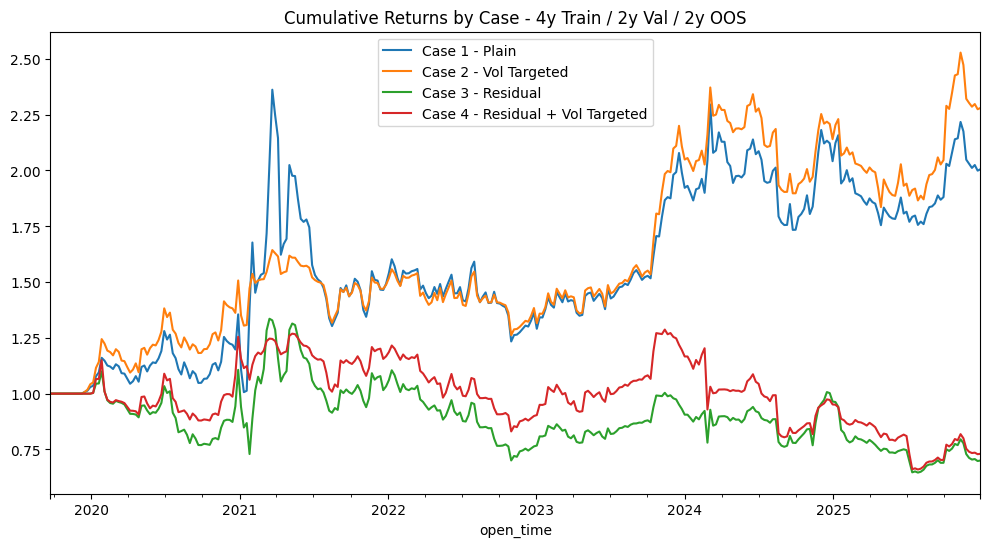

In [ ]:
# =========================================
# Section 12 - Cumulative Return Plots
# =========================================
plt.figure(figsize=(12, 6))
for case_name in case_map.keys():
    strat = all_extras[(case_name, split_name)]["strategy_train_val_oos"]
    cumulative_return(strat).plot(label=case_name)

plt.title("Cumulative Returns by Case - 4y Train / 2y Val / 2y OOS")
plt.legend()
plt.show()

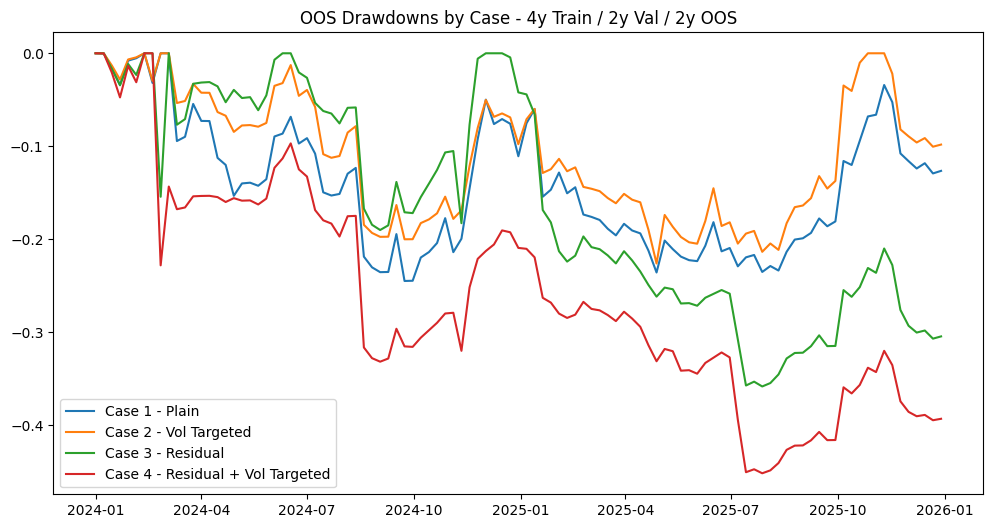

In [ ]:
# =========================================
# Section 13 - Drawdown Plots
# =========================================
plt.figure(figsize=(12, 6))
for case_name in case_map.keys():
    dd = all_extras[(case_name, split_name)]["oos_dd"]
    plt.plot(dd.index, dd.values, label=case_name)

plt.title("OOS Drawdowns by Case - 4y Train / 2y Val / 2y OOS")
plt.legend()
plt.show()

I have explored in this project a bunch of ideas: number of coins in the universe, transaction costs from 5bps to 20bps, longer lookbacks from 4weeks to 12 weeks. I have chosen weekly rebalancing to keep the trading costs lower and 4h sampling frequency to minimize market microstructure exposure while capturing intraday actions in crypto. I have tested plain t-stats from statsmodels as well as Newey-West t-stats, as I believe that the returns are correlated to each other and that returns has possible dependency on previous returns. Based on the validation results, the volatility-targeted momentum specification was selected as the preferred model. I am favouring in this return with the highest Sharpe and T-stat. This return also has the highest alpha in the test period regardless of the length of the test period. 4 weeks is chosen as the momentum lookback period as it captures recent activity and is more responsive, which improves the performance.